## QRM gain linearity test

Test to check the linearity of the QRM input gain

Author: Kyle MacRobbie

In [16]:
import sequence_helper as sh
import inspect
import math
import time
import json
import matplotlib.pyplot as plt # type: ignore
import pyvisa # type: ignore
import numpy as np # type: ignore
import scipy # type: ignore
from numpy import random # type: ignore
from __future__ import annotations 
from typing import TYPE_CHECKING, Callable
from qcodes.instrument import find_or_create_instrument # type: ignore
from qblox_instruments import Cluster, ClusterType # type: ignore
if TYPE_CHECKING:
    from qblox_instruments.qcodes_drivers.module import Module # type: ignore

In [17]:
# Connect to cluster
cluster_ip = "192.168.137.2"
cluster_name = "cluster0"
cluster = find_or_create_instrument(
    Cluster,
    recreate=True,
    name=cluster_name,
    identifier=cluster_ip,
    dummy_cfg=(
        {
            2: ClusterType.CLUSTER_QCM,
            4: ClusterType.CLUSTER_QRM,
            6: ClusterType.CLUSTER_QCM_RF,
        }
        if cluster_ip is None
        else None
    ),
)
cluster.led_brightness('medium') # Sets LED brightness on the modules. Options are 'low', 'medium' and 'high'
# Get modules, and connect to the QRM
def get_connected_modules(cluster: Cluster, filter_fn: Callable | None = None) -> dict[int, Module]:
    def checked_filter_fn(mod: ClusterType) -> bool:
        if filter_fn is not None:
            return filter_fn(mod)
        return True

    return {
        mod.slot_idx: mod for mod in cluster.modules if mod.present() and checked_filter_fn(mod)
    }
modules = get_connected_modules(cluster)
module = list(modules.values())[0]

cluster.led_brightness('medium')
cluster.reset()
print(cluster.get_system_status())
qrm_module = modules[4]
qcm_module = modules[2]
rf_module = modules[6]
# print("\nQCM: {}\nQRM: {}\nRF: {}".format(qrm_module.is_qcm_type, qrm_module.is_qrm_type, qrm_module.is_rf_type))
# print("\nQCM: {}\nQRM: {}\nRF: {}".format(qcm_module.is_qcm_type, qcm_module.is_qrm_type, qcm_module.is_rf_type))
# print("\nQCM: {}\nQRM: {}\nRF: {}".format(rf_module.is_qcm_type, rf_module.is_qrm_type, rf_module.is_rf_type))

Status: OKAY, Flags: NONE, Slot flags: NONE


In [13]:
amplitude = 0.1					# V
amplitude_q1 = amplitude / 0.5	# Value that gets put into the sequence, accounting for the QCM's output range
waveform_length = 10000			# ns

sequence_out = f""" 
	wait_sync		4			# Sync with other sequencers
	play			0,0,{waveform_length}	# Play waveform 0
	stop
"""

sequence_in = f""" 
	wait_sync		4			# Sync with other sequencers
	acquire			0,0,{waveform_length}	# Acquire to acquisition 0
	stop
"""

waveforms = {
	"block" : {
		"data": [amplitude_q1 for i in range(waveform_length)],
		"index": 0
	}
}

# Python code
acquisitions = {
	"acq": {"num_bins": 1, "index": 0}
}

sequence_dict_in = {
	"waveforms": {},
	"weights": {},
	"acquisitions": acquisitions,
	"program": sequence_in
}

sequence_dict_out = {
	"waveforms": waveforms,
	"weights": {},
	"acquisitions": {},
	"program": sequence_out
}

qrm_module.sequencer0.sequence(sequence_dict_in)			# Upload sequence
qrm_module.disconnect_outputs()								# Disconnect outputs
qrm_module.disconnect_inputs()								# Disconnect inputs
qrm_module.sequencer0.connect_acq_I("in1") 					# Connect to input 0 through path I
qrm_module.scope_acq_sequencer_select(0)					# Select sequencer 0 for scope mode 
qrm_module.scope_acq_trigger_mode_path0('sequencer')		# Trigger the acquisition with the sequence
qrm_module.sequencer0.delete_acquisition_data(all = True)	# Delete previous acquisition
qrm_module.sequencer0.integration_length_acq(1000)			# Set integration length
gain = qrm_module.in1_gain()
qrm_module.sequencer0.sync_en(True)							# Enable sync

qrm_module.sequencer1.sequence(sequence_dict_out)	# Upload sequence
qrm_module.disconnect_outputs()						# Disconnect outputs
qrm_module.sequencer1.connect_out0('I')				# Connect to input 0 on path I
qrm_module.sequencer1.sync_en(True)					# Enable sync to other sequencers

rf_module.sequencer0.sequence(sh.marker_only_sequence())
rf_module.sequencer0.sync_en(True)

rf_module.arm_sequencer(0)
qrm_module.arm_sequencer(0)						# Arm sequencer 0
qrm_module.arm_sequencer(1)						# Arm sequencer 1

print(gain)

-6


In [14]:
cluster.start_sequencer()

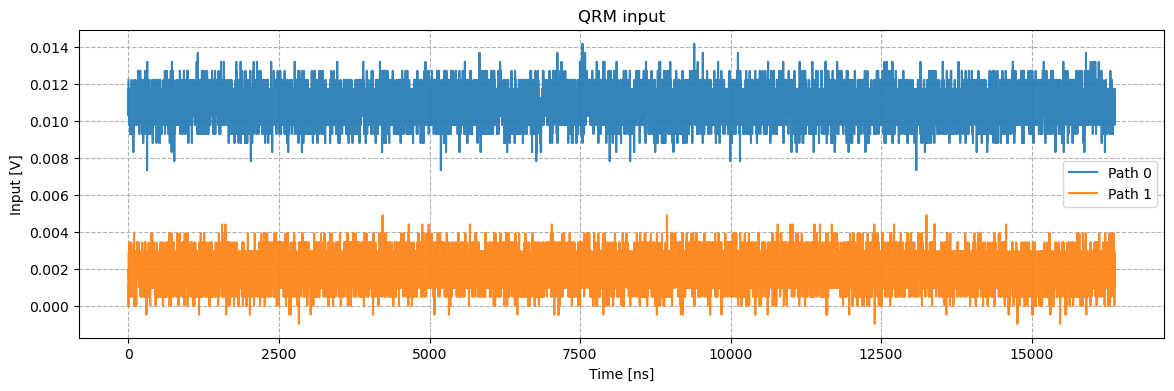

In [8]:
qrm_module.get_acquisition_status(0) 			# Wait for the sequencer to stop with a timeout period of one minute.
qrm_module.store_scope_acquisition(0, 'acq') 	# Move acquisition data from temporary memory to acquisition list.
readout_data = qrm_module.get_acquisitions(0) 	# Get acquisition list from instrument.
data0 = readout_data['acq']['acquisition']['scope']['path0']['data']
data1 = readout_data['acq']['acquisition']['scope']['path1']['data']
fig, ax = plt.subplots(1, 1, figsize = (14, 4))	# 
ax.plot(data0, alpha = 0.9, label = "Path 0")
ax.plot(data1, alpha = 0.9, label = "Path 1")
ax.set_title("QRM input")
ax.set_xlabel("Time [ns]")
ax.set_ylabel("Input [V]")
ax.grid(ls = '--')
plt.legend()
plt.show()

# name = f"{gain} dB"
# file = open(rf"C:\\Users\\BaughLaflamme\\Desktop\\Qblox Master Folder\\Miscellaneous\\Kyle MacRobbie\\QRM gain linearity tests\\Gain linearity data\\{name}.txt", "w")
# data_text = ""
# for point in data1:
# 	data_text += f"{str(point)}\n"
# file.write(data_text)
# file.close()

In [18]:
cluster.stop_sequencer()

print("QRM sequencer 0:    " + str(qrm_module.get_sequencer_status(0)))
print("QRM sequencer 1:    " + str(qrm_module.get_sequencer_status(1)))

# Reset the cluster
cluster.reset()
print(cluster.get_system_status())

QRM sequencer 0:    Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
QRM sequencer 1:    Status: OKAY, State: STOPPED, Info Flags: FORCED_STOP, Warning Flags: NONE, Error Flags: NONE, Log: []
Status: OKAY, Flags: NONE, Slot flags: NONE
